In [1]:
SEED = 42
import os, sys, importlib.util

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ROOT_PATH = '/content/drive/MyDrive/SAND'
if ROOT_PATH not in sys.path:
    sys.path.append(ROOT_PATH)




os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sand.experiments.datasets.dataset import get_dataset
from sand.experiments.models.mlp_sand import SANDModel as OriginalSANDModel

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    tf.random.set_seed(seed)          # YENİ: açıkça tekrar set et
    try:
        tf.config.experimental.enable_op_determinism()   # YENİ: clear_session sonrası her çağrıda yeniden aktif et
    except Exception as e:
        print("Determinism ayarı uygulanamadı:", e)


Mounted at /content/drive


In [2]:
# Projenin kod içerisinde veriyi aradığı ana dizin (sabit tutulmalı)
local_datasets_path = '/content/drive/MyDrive/SAND/sand/experiments/datasets'

# Drive'daki gerçek veri dosyalarınızın olduğu klasör
drive_datasets_path = '/content/drive/MyDrive/SAND/datasets'

# Klasör eşleştirmeleri (Drive Klasör Adı: Proje Klasör Adı)
dataset_mapping = {
    'har70': 'activity/UCI HAR Dataset',
    'coil': 'coil/coil-20-proc',
    'isolet': 'isolet',
    'mice': 'mice',
    'arcene': "arcene"
}

print("🔗 Veri yolları Drive klasörleri arasında bağlanıyor...")

for drive_folder, local_rel_path in dataset_mapping.items():
    full_local_path = os.path.join(local_datasets_path, local_rel_path)
    full_drive_path = os.path.join(drive_datasets_path, drive_folder)

    # Hedef dizini oluştur
    target_dir = os.path.dirname(full_local_path)
    os.makedirs(target_dir, exist_ok=True)

    # Eğer sembolik bağ daha önce yanlış oluşturulmuşsa silelim
    if os.path.islink(full_local_path) or os.path.exists(full_local_path):
        !rm -rf "{full_local_path}"

    # Sembolik bağ oluştur: Kodun aradığı yer -> Drive'daki gerçek yer
    !ln -s "{full_drive_path}" "{full_local_path}"
    print(f"✅ {full_local_path} -> {full_drive_path}")

🔗 Veri yolları Drive klasörleri arasında bağlanıyor...
ln: failed to create symbolic link '/content/drive/MyDrive/SAND/sand/experiments/datasets/activity/UCI HAR Dataset': Operation not supported
✅ /content/drive/MyDrive/SAND/sand/experiments/datasets/activity/UCI HAR Dataset -> /content/drive/MyDrive/SAND/datasets/har70
ln: failed to create symbolic link '/content/drive/MyDrive/SAND/sand/experiments/datasets/coil/coil-20-proc': Operation not supported
✅ /content/drive/MyDrive/SAND/sand/experiments/datasets/coil/coil-20-proc -> /content/drive/MyDrive/SAND/datasets/coil
ln: failed to create symbolic link '/content/drive/MyDrive/SAND/sand/experiments/datasets/isolet': Operation not supported
✅ /content/drive/MyDrive/SAND/sand/experiments/datasets/isolet -> /content/drive/MyDrive/SAND/datasets/isolet
ln: failed to create symbolic link '/content/drive/MyDrive/SAND/sand/experiments/datasets/mice': Operation not supported
✅ /content/drive/MyDrive/SAND/sand/experiments/datasets/mice -> /conte

In [3]:
MODULE_PATH = os.path.join(ROOT_PATH, 'adaptive_sand.py')
MODULE_NAME = 'sand_drive'

if MODULE_NAME in sys.modules:
    del sys.modules[MODULE_NAME]

spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
sand_module = importlib.util.module_from_spec(spec)
sys.modules[MODULE_NAME] = sand_module
spec.loader.exec_module(sand_module)

SANDAdaptiveModel = sand_module.SANDAdaptiveModel
print("A-SAND (first-order) module loaded.")

A-SAND (first-order) module loaded.


In [4]:
import numpy as np
import tensorflow as tf


class SANDLayerUniversalHybrid(tf.keras.layers.Layer):
    """
    A-SAND-Hybrid için adaptif özellik seçme katmanı.

    Birinci derece gradyan büyüklüklerini ve Hutchinson tabanlı
    ikinci derece diagonal Hessian tahminlerini biriktirir.
    """

    def __init__(self, num_inputs, initial_k=None, **kwargs):
        super().__init__(**kwargs)

        self.num_features = int(num_inputs)

        self.k = tf.Variable(
            initial_k if initial_k is not None else self.num_features,
            trainable=False,
            dtype=tf.int32,
            name="selected_feature_count"
        )

        self.hessian_rng = tf.random.Generator.from_seed(2026)
        self.noise_rng = tf.random.Generator.from_seed(42)

        self.w = self.add_weight(
            shape=(self.num_features,),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=0.05,
                seed=42
            ),
            trainable=True,
            name="feature_weights"
        )

        self.mask = tf.Variable(
            tf.ones(self.num_features, dtype=tf.float32),
            trainable=False,
            name="feature_mask"
        )

        self.best_mask = tf.Variable(
            tf.ones(self.num_features, dtype=tf.float32),
            trainable=False,
            name="best_feature_mask"
        )

        self.best_k = tf.Variable(
            initial_k if initial_k is not None else self.num_features,
            trainable=False,
            dtype=tf.int32,
            name="best_selected_feature_count"
        )

        self.pruning_active = True

        self.grad_accumulator = tf.Variable(
            tf.zeros(self.num_features, dtype=tf.float32),
            trainable=False,
            name="gradient_accumulator"
        )

        self.grad_count = tf.Variable(
            0.0,
            trainable=False,
            dtype=tf.float32,
            name="gradient_count"
        )

        self.hdiag_accumulator = tf.Variable(
            tf.zeros(self.num_features, dtype=tf.float32),
            trainable=False,
            name="hessian_diagonal_accumulator"
        )

        self.hdiag_count = tf.Variable(
            0.0,
            trainable=False,
            dtype=tf.float32,
            name="hessian_diagonal_count"
        )

    def enforce_mask(self):
        """Budanmış ağırlıkları kalıcı biçimde sıfırlar."""
        self.w.assign(self.w * self.mask)

    def call(self, x, training=False):
        self.enforce_mask()

        w_abs = tf.minimum(tf.abs(self.w), 1.0)
        w_active = w_abs * self.mask

        norm = tf.sqrt(
            tf.reduce_sum(tf.square(w_active)) + 1e-8
        )

        normalized_weights = (
            w_active / norm
        ) * tf.sqrt(tf.cast(self.k, tf.float32))

        x_weighted = x * normalized_weights

        if training:
            noise_std = 0.5 * tf.abs(1.0 - normalized_weights)

            noise = self.noise_rng.normal(
                shape=tf.shape(x_weighted),
                mean=0.0,
                stddev=noise_std,
                dtype=x_weighted.dtype
            )

            return x_weighted + noise

        return x_weighted

    def record_gradients(self, gradients):
        """Aktif özelliklerin mutlak birinci derece önemini biriktirir."""
        if gradients is None or not self.pruning_active:
            return

        gradients = tf.where(
            tf.math.is_finite(gradients),
            gradients,
            tf.zeros_like(gradients)
        )

        gradient_scores = tf.abs(gradients) * self.mask

        self.grad_accumulator.assign_add(gradient_scores)
        self.grad_count.assign_add(1.0)

    def record_hdiag(self, hdiag):
        """Hutchinson ile hesaplanan Hessian diagonal tahminini biriktirir."""
        if hdiag is None or not self.pruning_active:
            return

        hdiag = tf.where(
            tf.math.is_finite(hdiag),
            hdiag,
            tf.zeros_like(hdiag)
        )

        hdiag = tf.maximum(hdiag, 0.0)
        hdiag = hdiag * self.mask

        self.hdiag_accumulator.assign_add(hdiag)
        self.hdiag_count.assign_add(1.0)

    def save_current_as_best(self):
        """Katman düzeyindeki mask/k durumunu kaydeder."""
        self.best_mask.assign(self.mask)
        self.best_k.assign(self.k)

    def restore_best(self):
        """Katman düzeyindeki mask/k durumunu geri yükler."""
        self.mask.assign(self.best_mask)
        self.k.assign(self.best_k)
        self.enforce_mask()

    def reset_importance_buffers(self):
        """Her budama sonrasında önem istatistiklerini sıfırlar."""
        self.grad_accumulator.assign(
            tf.zeros(self.num_features, dtype=tf.float32)
        )

        self.grad_count.assign(0.0)

        self.hdiag_accumulator.assign(
            tf.zeros(self.num_features, dtype=tf.float32)
        )

        self.hdiag_count.assign(0.0)

    def _first_order_scores(self):
        """Ortalama mutlak gradyana dayalı önem skorları."""
        mask = self.mask.numpy()

        if self.grad_count.numpy() > 0:
            scores = (
                self.grad_accumulator.numpy()
                / self.grad_count.numpy()
            )
        else:
            scores = np.abs(self.w.numpy())

        scores = scores.copy()
        scores[mask == 0] = -np.inf

        return scores

    def _second_order_scores(self):
        """0.5 * H_ii * w_i^2 biçimindeki ikinci derece skorlar."""
        if self.hdiag_count.numpy() > 0:
            hdiag = (
                self.hdiag_accumulator.numpy()
                / self.hdiag_count.numpy()
            )
        else:
            hdiag = np.zeros_like(self.w.numpy())

        scores = 0.5 * hdiag * np.square(self.w.numpy())
        scores = scores.copy()

        scores[self.mask.numpy() == 0] = -np.inf

        return scores

    def second_order_scores(self):
        """Geriye uyumluluk için public ikinci-derece skor metodu."""
        return self._second_order_scores()

    def _apply_prune(
        self,
        scores,
        force_target_k=None,
        prune_rate=0.10
    ):
        """Skoru düşük aktif özellikleri maskeden çıkarır."""
        current_mask = self.mask.numpy()
        k_old = int(np.sum(current_mask))

        if k_old <= 1:
            return k_old, k_old

        if force_target_k is not None:
            num_to_keep = int(force_target_k)
        else:
            num_to_prune = max(1, int(prune_rate * k_old))
            num_to_keep = k_old - num_to_prune

        num_to_keep = max(1, min(num_to_keep, k_old))

        # Eşit skorlarda deterministik seçim sağlar.
        tie_breaker = 1e-12 * np.arange(len(scores))
        stable_scores = scores + tie_breaker

        top_idx = np.argsort(stable_scores)[-num_to_keep:]

        new_mask = np.zeros_like(
            current_mask,
            dtype=np.float32
        )

        new_mask[top_idx] = 1.0

        self.mask.assign(new_mask)
        self.k.assign(int(np.sum(new_mask)))

        self.enforce_mask()
        self.reset_importance_buffers()

        return k_old, int(self.k.numpy())

    def prune_by_gradient(
        self,
        force_target_k=None,
        prune_rate=0.10
    ):
        """Sadece birinci derece önem skoruyla budama yapar."""
        if not self.pruning_active:
            return False

        self._apply_prune(
            scores=self._first_order_scores(),
            force_target_k=force_target_k,
            prune_rate=prune_rate
        )

        return True

    def prune_by_hybrid(
        self,
        alpha=0.7,
        force_target_k=None,
        prune_rate=0.10
    ):
        """
        Birinci ve ikinci derece skorları normalize edip birleştirir.

        alpha=1.0 yalnızca gradient; alpha=0.0 yalnızca Hessian
        skorunu ifade eder.
        """
        if not self.pruning_active:
            return False

        alpha = float(np.clip(alpha, 0.0, 1.0))

        first_order = self._first_order_scores()
        second_order = self._second_order_scores()

        finite_g = first_order[np.isfinite(first_order)]
        finite_h = second_order[np.isfinite(second_order)]

        if finite_g.size > 0 and finite_g.std() > 1e-12:
            g_normalized = (
                first_order - finite_g.mean()
            ) / (finite_g.std() + 1e-8)
        else:
            g_normalized = first_order.copy()

        if finite_h.size > 0 and finite_h.std() > 1e-12:
            h_normalized = (
                second_order - finite_h.mean()
            ) / (finite_h.std() + 1e-8)
        else:
            h_normalized = second_order.copy()

        hybrid_scores = (
            alpha * g_normalized
            + (1.0 - alpha) * h_normalized
        )

        hybrid_scores = hybrid_scores.copy()
        hybrid_scores[self.mask.numpy() == 0] = -np.inf

        self._apply_prune(
            scores=hybrid_scores,
            force_target_k=force_target_k,
            prune_rate=prune_rate
        )

        return True

    def get_feature_importance(self):
        return {
            "num_selected": int(np.sum(self.mask.numpy())),
            "mask": self.mask.numpy().copy(),
            "first_order_scores": self._first_order_scores(),
            "second_order_scores": self._second_order_scores(),
        }


class SANDAdaptiveModelHybrid(tf.keras.Model):
    """A-SAND-Hybrid: birinci + ikinci derece özellik seçimi yapan MLP."""

    def __init__(
        self,
        num_inputs,
        num_outputs,
        initial_k=None,
        layer_sequence=(67,),
        is_classification=True,
        alpha=0.0,
        batch_norm=False,
        learning_rate=1e-4,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.is_classification = is_classification
        self.batch_norm = batch_norm
        self.learning_rate = learning_rate

        self.selector = SANDLayerUniversalHybrid(
            num_inputs=num_inputs,
            initial_k=initial_k
        )

        if self.batch_norm:
            self.bn = tf.keras.layers.BatchNormalization(
                name="batch_normalization"
            )

        self.hidden = [
            tf.keras.layers.Dense(
                units=units,
                activation=tf.keras.layers.LeakyReLU(
                    negative_slope=alpha
                ),
                kernel_initializer=tf.keras.initializers.GlorotUniform(
                    seed=42 + i
                ),
                name=f"hidden_{i}"
            )
            for i, units in enumerate(layer_sequence)
        ]

        if self.is_classification:
            self.out = tf.keras.layers.Dense(
                num_outputs,
                activation="softmax",
                kernel_initializer=tf.keras.initializers.GlorotUniform(
                    seed=100
                ),
                name="classification_output"
            )

            self.loss_fn = tf.keras.losses.CategoricalCrossentropy()

            self.acc_metric = tf.keras.metrics.CategoricalAccuracy(
                name="accuracy"
            )

        else:
            self.out = tf.keras.layers.Dense(
                num_outputs,
                kernel_initializer=tf.keras.initializers.GlorotUniform(
                    seed=100
                ),
                name="regression_output"
            )

            self.loss_fn = tf.keras.losses.MeanSquaredError()
            self.acc_metric = None

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    def compile(self, optimizer=None, **kwargs):
        """
        Deney kodundaki model_hybrid.compile() çağrısının
        Adam(1e-4) ile doğrudan çalışmasını sağlar.
        """
        if optimizer is None:
            optimizer = tf.keras.optimizers.Adam(
                learning_rate=self.learning_rate
            )

        super().compile(
            optimizer=optimizer,
            **kwargs
        )

    @property
    def metrics(self):
        metric_list = [self.loss_tracker]

        if self.acc_metric is not None:
            metric_list.append(self.acc_metric)

        return metric_list

    def call(self, x, training=False):
        x = self.selector(x, training=training)

        if self.batch_norm:
            x = self.bn(x, training=training)

        for layer in self.hidden:
            x = layer(x, training=training)

        return self.out(x, training=training)

    def train_step(self, data):
        x, y = data

        with tf.GradientTape(persistent=True) as outer_tape:
            with tf.GradientTape() as inner_tape:
                y_pred = self(x, training=True)
                loss = self.loss_fn(y, y_pred)

            grad_w = inner_tape.gradient(
                loss,
                self.selector.w
            )

            if grad_w is None:
                raise RuntimeError(
                    "Gradient for selector weights could not be computed."
                )

            rademacher = tf.where(
                self.selector.hessian_rng.uniform(
                    shape=tf.shape(self.selector.w),
                    minval=0.0,
                    maxval=1.0,
                    dtype=tf.float32
                ) < 0.5,
                -tf.ones_like(self.selector.w),
                tf.ones_like(self.selector.w)
            )

            directional_grad = tf.reduce_sum(
                grad_w * tf.stop_gradient(rademacher)
            )

        hessian_vector_product = outer_tape.gradient(
            directional_grad,
            self.selector.w
        )

        train_vars = self.trainable_variables

        gradients = outer_tape.gradient(
            loss,
            train_vars
        )

        del outer_tape

        self.selector.record_gradients(grad_w)

        if hessian_vector_product is not None:
            hdiag_estimate = rademacher * hessian_vector_product
            self.selector.record_hdiag(hdiag_estimate)

        self.optimizer.apply_gradients(
            (grad, variable)
            for grad, variable in zip(gradients, train_vars)
            if grad is not None
        )

        self.selector.enforce_mask()

        self.loss_tracker.update_state(loss)

        if self.acc_metric is not None:
            self.acc_metric.update_state(y, y_pred)

        return {
            metric.name: metric.result()
            for metric in self.metrics
        }

    def test_step(self, data):
        x, y = data

        y_pred = self(x, training=False)
        loss = self.loss_fn(y, y_pred)

        self.loss_tracker.update_state(loss)

        if self.acc_metric is not None:
            self.acc_metric.update_state(y, y_pred)

        return {
            metric.name: metric.result()
            for metric in self.metrics
        }

    def get_feature_importance(self):
        return self.selector.get_feature_importance()


print("A-SAND-Hybrid model defined.")

A-SAND-Hybrid model defined.


In [5]:
class _BasePlateauPruningCallback(tf.keras.callbacks.Callback):
    """Shared plateau-detection and accept/reject logic for A-SAND variants."""

    def __init__(self, start_epoch=5, interval=4, tolerance=0.005, lambda_k=0.15,
                 plateau_window=3, plateau_tol=0.003, cooldown=3, max_rejections=3,
                 prune_rate=0.10):
        super().__init__()
        self.start_epoch = start_epoch
        self.interval = interval
        self.tolerance = tolerance
        self.lambda_k = lambda_k
        self.plateau_window = plateau_window
        self.plateau_tol = plateau_tol
        self.cooldown = cooldown
        self.max_rejections = max_rejections
        self.prune_rate = prune_rate

        self.best_score = -np.inf
        self.pending_prune = False
        self.backup_mask = self.backup_k = self.backup_weights = None
        self.last_prune_epoch = -999
        self.rejected_targets = {}
        self.input_dim = None
        self.full_acc_history = []
        self.prune_epochs = []
        self.best_weights = None
        self.best_mask = None
        self.best_k = None

    def compute_score(self, val_acc, k):
        return val_acc - self.lambda_k * (k / self.input_dim) ** 1.5

    def is_plateaued(self):
        if len(self.full_acc_history) <= self.plateau_window + 1:
            return False
        recent = self.full_acc_history[-(self.plateau_window + 1):]
        diffs = [abs(recent[i] - recent[i - 1]) for i in range(1, len(recent))]
        return max(diffs) <= self.plateau_tol

    def on_train_begin(self, logs=None):
        self.input_dim = self.model.selector.num_features

    def _do_prune(self, selector, epoch):
        raise NotImplementedError

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        val_acc = float(logs.get("val_accuracy", 0.0))
        self.full_acc_history.append(val_acc)

        selector = self.model.selector
        current_k = int(selector.k.numpy())
        current_score = self.compute_score(val_acc, current_k)

        # 1) Bir önceki epoch'ta budama yapıldıysa,
        # önce o budamanın kabul/red kararını ver.
        if self.pending_prune:
            candidate_score = current_score

            if candidate_score >= self.backup_score - self.tolerance:
                # Budama kabul edildi.
                self.pending_prune = False
                self.rejected_targets.pop(int(self.backup_k), None)

                if self.best_weights is None or candidate_score > self.best_score:
                    self.save_best_state(selector, candidate_score)

            else:
                # Budama reddedildi: weights + mask + k birlikte geri alınır.
                self.model.set_weights(self.backup_weights)

                selector.mask.assign(
                    self.backup_mask.astype(np.float32)
                )
                selector.k.assign(self.backup_k)
                selector.enforce_mask()

                old_k = int(self.backup_k)
                self.rejected_targets[old_k] = (
                    self.rejected_targets.get(old_k, 0) + 1
                )

                self.pending_prune = False

            return

        # 2) Normal epoch: mevcut model gerçek bir adaydır.
        if self.best_weights is None or current_score > self.best_score:
            self.save_best_state(selector, current_score)

        rejection_count = self.rejected_targets.get(current_k, 0)

        can_prune = (
            epoch >= self.start_epoch
            and (epoch - self.start_epoch) % self.interval == 0
            and (epoch - self.last_prune_epoch) >= self.cooldown
            and self.is_plateaued()
            and rejection_count < self.max_rejections
            and current_k > 1
        )

        if not can_prune:
            return

        # 3) Budama öncesindeki tüm durum yedeklenir.
        self.backup_weights = [
            weight.copy()
            for weight in self.model.get_weights()
        ]

        self.backup_mask = selector.mask.numpy().copy()
        self.backup_k = int(selector.k.numpy())
        self.backup_score = self.compute_score(
            val_acc,
            self.backup_k
        )

        self._do_prune(selector, epoch)

        self.last_prune_epoch = epoch
        self.prune_epochs.append(epoch)
        self.pending_prune = True

    def save_best_state(self, selector, score):
        self.best_score = float(score)

        self.best_weights = [
            weight.copy()
            for weight in self.model.get_weights()
        ]

        self.best_mask = selector.mask.numpy().copy()
        self.best_k = int(selector.k.numpy())


    def restore_best_state(self):
        if self.best_weights is None:
            raise RuntimeError("Best model state was never initialized.")

        self.model.set_weights(self.best_weights)

        selector = self.model.selector
        selector.mask.assign(self.best_mask.astype(np.float32))
        selector.k.assign(self.best_k)
        selector.enforce_mask()

    def on_train_end(self, logs=None):
        self.restore_best_state()

class SANDSmartPruningCallback(_BasePlateauPruningCallback):
    """First-order (gradient-based) plateau pruning callback for A-SAND."""

    def _do_prune(self, selector, epoch):
        selector.prune_by_gradient(prune_rate=self.prune_rate)


class SANDSmartHybridPruningCallback(_BasePlateauPruningCallback):
    """First+second-order plateau pruning callback for A-SAND-Hybrid."""

    def __init__(self, hybrid_alpha=0.7, **kwargs):
        super().__init__(**kwargs)
        self.hybrid_alpha = hybrid_alpha

    def _do_prune(self, selector, epoch):
        selector.prune_by_hybrid(alpha=self.hybrid_alpha, prune_rate=self.prune_rate)


print("Plateau-based pruning callbacks defined.")

Plateau-based pruning callbacks defined.


In [6]:
def dataset_to_numpy(ds):
    xs, ys = [], []

    for xb, yb in ds:
        xs.append(xb.numpy())
        ys.append(yb.numpy())

    return np.concatenate(xs, axis=0), np.concatenate(ys, axis=0)


def load_prepared_dataset(dataset_name, val_ratio=0.125, batch_size=32, seed=42):
    data = get_dataset(
        dataname=dataset_name,
        valratio=val_ratio,
        batchsize=batch_size,
        seed=seed
    )

    return {
        "ds_train": data["dstrain"],
        "ds_val": data["dsval"],
        "ds_test": data["dstest"],

        "x_train": data["xtrain"],
        "y_train": data["ytrain"],
        "x_val": data["xval"],
        "y_val": data["yval"],
        "x_test": data["xtest"],
        "y_test": data["ytest"],

        "num_features": data["numfeatures"],
        "num_classes": data["numclasses"],
        "is_classification": data["isclassification"],
    }

In [7]:
from sklearn.linear_model import LogisticRegression
def build_classifier_mlp(input_dim, num_classes, seed=42):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(
            67,
            activation=tf.keras.layers.LeakyReLU(negative_slope=0.0),
            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed)
        ),
        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed)
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")]
    )

    return model

In [8]:
import time
import os
import gc
import psutil
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.linear_model import LogisticRegression


# ------------------------- CONFIGURATION -------------------------
DATASET_NAME = "mnist"          # "mice", "isolet", "coil", "mnist", "arcene"
EPOCHS = 150
FIXED_K = 60
LAYER_SEQUENCE = (67,)
HYBRID_ALPHA = 0.7

RESULTS_CSV = os.path.join(
    ROOT_PATH,
    "results",
    f"unified_comparison_{DATASET_NAME}.csv"
)

os.makedirs(os.path.dirname(RESULTS_CSV), exist_ok=True)
# -------------------------------------------------------------------


process = psutil.Process(os.getpid())


def reset_memory_counters():
    gc.collect()

    try:
        tf.config.experimental.reset_memory_stats("GPU:0")
    except (ValueError, tf.errors.InvalidArgumentError):
        pass


def get_memory_metrics():
    rss_mb = process.memory_info().rss / (1024 ** 2)

    try:
        gpu_info = tf.config.experimental.get_memory_info("GPU:0")

        gpu_current_mb = gpu_info["current"] / (1024 ** 2)
        gpu_peak_mb = gpu_info["peak"] / (1024 ** 2)

    except (ValueError, tf.errors.InvalidArgumentError):
        gpu_current_mb = np.nan
        gpu_peak_mb = np.nan

    return {
        "gpu_current_mb": gpu_current_mb,
        "gpu_peak_mb": gpu_peak_mb,
        "rss_mb": rss_mb,
    }


def run_all_models(
    dataset_name,
    epochs=EPOCHS,
    fixed_k=FIXED_K,
    seed=42
):
    reset_seeds(seed)

    print("=" * 90)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 90)

    data = load_prepared_dataset(dataset_name, seed=seed)

    ds_train = data["ds_train"]
    ds_val = data["ds_val"]
    ds_test = data["ds_test"]

    num_features = data["num_features"]
    num_classes = data["num_classes"]

    loss_fn = tf.keras.losses.CategoricalCrossentropy()

    X_train, y_train = dataset_to_numpy(ds_train)
    X_val, y_val = dataset_to_numpy(ds_val)
    X_test, y_test = dataset_to_numpy(ds_test)

    if y_train.ndim > 1:
        y_train = np.argmax(y_train, axis=1)
        y_val = np.argmax(y_val, axis=1)
        y_test = np.argmax(y_test, axis=1)

    results = []

    # ================================================================
    # 1. A-SAND — First-order automatic feature selection
    # ================================================================
    tf.keras.backend.clear_session()
    gc.collect()
    reset_memory_counters()
    reset_seeds(seed)

    print("\n[1/4] A-SAND (first-order) ...")

    model_asand = SANDAdaptiveModel(
        num_inputs=num_features,
        num_outputs=num_classes,
        initial_k=num_features,
        layer_sequence=LAYER_SEQUENCE,
        is_classification=True
    )

    model_asand.compile(
        loss=loss_fn,
        metrics=["accuracy"]
    )

    cb_asand = SANDSmartPruningCallback()

    reset_memory_counters()
    rss_before_asand = process.memory_info().rss / (1024 ** 2)

    t0 = time.time()

    model_asand.fit(
        ds_train,
        validation_data=ds_val,
        epochs=epochs,
        callbacks=[cb_asand],
        verbose=0
    )

    t_asand = time.time() - t0

    mem_asand = get_memory_metrics()

    mem_asand_rss_delta_mb = (
        mem_asand["rss_mb"] - rss_before_asand
    )

    res_asand = model_asand.evaluate(
        ds_test,
        return_dict=True,
        verbose=0
    )

    k_asand = model_asand.get_feature_importance()["num_selected"]

    results.append({
        "model": "A-SAND",
        "k_strategy": "auto",
        "accuracy": float(res_asand["accuracy"]),
        "k": int(k_asand),
        "time_sec": float(t_asand),
        "gpu_peak_mb": mem_asand["gpu_peak_mb"],
        "rss_mb": mem_asand["rss_mb"],
        "rss_delta_mb": mem_asand_rss_delta_mb,
    })

    del model_asand
    del cb_asand

    gc.collect()
    tf.keras.backend.clear_session()

    # ================================================================
    # 2. A-SAND-Hybrid — First + second-order automatic selection
    # ================================================================
    reset_memory_counters()
    reset_seeds(seed)

    print("[2/4] A-SAND-Hybrid (first+second-order) ...")

    model_hybrid = SANDAdaptiveModelHybrid(
        num_inputs=num_features,
        num_outputs=num_classes,
        initial_k=num_features,
        layer_sequence=LAYER_SEQUENCE,
        is_classification=True,
        batch_norm=False
    )

    model_hybrid.compile()

    cb_hybrid = SANDSmartHybridPruningCallback(
        hybrid_alpha=HYBRID_ALPHA
    )

    reset_memory_counters()
    rss_before_hybrid = process.memory_info().rss / (1024 ** 2)

    t0 = time.time()

    model_hybrid.fit(
        ds_train,
        validation_data=ds_val,
        epochs=epochs,
        callbacks=[cb_hybrid],
        verbose=0
    )

    t_hybrid = time.time() - t0

    mem_hybrid = get_memory_metrics()

    mem_hybrid_rss_delta_mb = (
        mem_hybrid["rss_mb"] - rss_before_hybrid
    )

    res_hybrid = model_hybrid.evaluate(
        ds_test,
        return_dict=True,
        verbose=0
    )

    print("Hybrid evaluation sonucu:", res_hybrid)
    print("Hybrid metrics:", model_hybrid.metrics_names)

    if "accuracy" not in res_hybrid:
        raise RuntimeError(
            "Hybrid evaluate sonucu 'accuracy' içermiyor. "
            f"Gelen sonuç: {res_hybrid}"
        )

    k_hybrid = model_hybrid.get_feature_importance()["num_selected"]

    results.append({
        "model": "A-SAND-Hybrid",
        "k_strategy": "auto",
        "accuracy": float(res_hybrid["accuracy"]),
        "k": int(k_hybrid),
        "time_sec": float(t_hybrid),
        "gpu_peak_mb": mem_hybrid["gpu_peak_mb"],
        "rss_mb": mem_hybrid["rss_mb"],
        "rss_delta_mb": mem_hybrid_rss_delta_mb,
    })

    del model_hybrid
    del cb_hybrid

    gc.collect()
    tf.keras.backend.clear_session()

    # ================================================================
    # 3. Baseline modellerde denenecek k değerleri
    # ================================================================
    k_targets = sorted(
        set([
            min(fixed_k, num_features),
            int(k_asand),
            int(k_hybrid)
        ])
    )

    print(
        f"\nBaseline modeller şu k değerlerinde test edilecek: "
        f"{k_targets}"
    )

    def k_label(k_val):
        if k_val == fixed_k:
            return "fixed"

        if k_val == k_asand:
            return "matched_asand"

        if k_val == k_hybrid:
            return "matched_hybrid"

        return "custom"

    # ================================================================
    # 3a. Original SAND — Her k değeri için
    # ================================================================
    for k_val in k_targets:
        label = k_label(k_val)

        tf.keras.backend.clear_session()
        gc.collect()
        reset_memory_counters()
        reset_seeds(seed)

        print(f"[3/4] Original SAND @ k={k_val} ({label}) ...")

        model_orig = OriginalSANDModel(
            num_inputs=num_features,
            num_inputs_to_select=k_val,
            sigma=1.5,
            layer_sequence=LAYER_SEQUENCE,
            is_classification=True,
            num_classes=num_classes,
            learning_rate=1e-4,
            decay_steps=250,
            decay_rate=1.0,
            alpha=0,
            batch_norm=False
        )

        model_orig.compile(
            loss=loss_fn,
            metrics=["accuracy"]
        )

        reset_memory_counters()
        rss_before_orig = process.memory_info().rss / (1024 ** 2)

        t0 = time.time()

        model_orig.fit(
            ds_train,
            validation_data=ds_val,
            epochs=epochs,
            verbose=0
        )

        t_orig = time.time() - t0

        mem_orig = get_memory_metrics()

        mem_orig_rss_delta_mb = (
            mem_orig["rss_mb"] - rss_before_orig
        )

        res_orig = model_orig.evaluate(
            ds_test,
            return_dict=True,
            verbose=0
        )

        results.append({
            "model": "Original SAND",
            "k_strategy": label,
            "accuracy": float(res_orig["accuracy"]),
            "k": int(k_val),
            "time_sec": float(t_orig),
            "gpu_peak_mb": mem_orig["gpu_peak_mb"],
            "rss_mb": mem_orig["rss_mb"],
            "rss_delta_mb": mem_orig_rss_delta_mb,
        })

        del model_orig

        gc.collect()
        tf.keras.backend.clear_session()

    # ================================================================
    # 3b. L1-Logistic Regression + MLP — Her k değeri için
    # ================================================================
    for k_val in k_targets:
        label = k_label(k_val)

        tf.keras.backend.clear_session()
        gc.collect()
        reset_memory_counters()
        reset_seeds(seed)

        print(f"[4/4] L1-Logistic + MLP @ k={k_val} ({label}) ...")

        rss_before_l1 = process.memory_info().rss / (1024 ** 2)

        t0 = time.time()

        l1_selector = LogisticRegression(
            penalty="l1",
            solver="saga",
            multi_class="multinomial",
            C=1.0,
            max_iter=5000,
            tol=1e-4,
            random_state=seed,
            n_jobs=-1
        )

        l1_selector.fit(X_train, y_train)

        coef_abs = np.abs(l1_selector.coef_)

        if coef_abs.ndim == 1:
            feature_scores = coef_abs
        else:
            feature_scores = np.max(coef_abs, axis=0)

        k_val = min(k_val, X_train.shape[1])

        top_idx = np.argsort(feature_scores)[-k_val:]

        X_train_sel = X_train[:, top_idx]
        X_val_sel = X_val[:, top_idx]
        X_test_sel = X_test[:, top_idx]

        model_l1_mlp = build_classifier_mlp(
            input_dim=X_train_sel.shape[1],
            num_classes=num_classes,
            seed=seed
        )

        model_l1_mlp.fit(
            X_train_sel,
            tf.keras.utils.to_categorical(
                y_train,
                num_classes
            ),
            validation_data=(
                X_val_sel,
                tf.keras.utils.to_categorical(
                    y_val,
                    num_classes
                )
            ),
            epochs=epochs,
            batch_size=32,
            verbose=0
        )

        t_l1_mlp = time.time() - t0

        mem_l1_mlp = get_memory_metrics()

        mem_l1_mlp_rss_delta_mb = (
            mem_l1_mlp["rss_mb"] - rss_before_l1
        )

        res_l1_mlp = model_l1_mlp.evaluate(
            X_test_sel,
            tf.keras.utils.to_categorical(
                y_test,
                num_classes
            ),
            return_dict=True,
            verbose=0
        )

        results.append({
            "model": "L1-Logistic + MLP",
            "k_strategy": label,
            "accuracy": float(res_l1_mlp["accuracy"]),
            "k": int(X_train_sel.shape[1]),
            "time_sec": float(t_l1_mlp),
            "gpu_peak_mb": mem_l1_mlp["gpu_peak_mb"],
            "rss_mb": mem_l1_mlp["rss_mb"],
            "rss_delta_mb": mem_l1_mlp_rss_delta_mb,
        })

        del l1_selector
        del model_l1_mlp

        gc.collect()
        tf.keras.backend.clear_session()

    # ================================================================
    # Rapor ve CSV
    # ================================================================
    df = pd.DataFrame(results)

    df["dataset"] = dataset_name
    df["k_ratio"] = df["k"] / num_features

    column_order = [
        "dataset",
        "model",
        "k_strategy",
        "accuracy",
        "k",
        "k_ratio",
        "time_sec",
        "gpu_peak_mb",
        "rss_mb",
        "rss_delta_mb",
    ]

    df = df[column_order]

    print("\n" + "=" * 90)
    print(f"FINAL COMPARISON MATRIX — {dataset_name.upper()}")
    print("=" * 90)

    print(
        df.to_string(
            index=False,
            float_format=lambda value: f"{value:.6f}"
        )
    )

    # Her yeni çalıştırmada dosyayı temiz biçimde yeniden yazar.
    # Aynı sonuçların CSV'ye tekrar tekrar eklenmesini önler.
    df.to_csv(
        RESULTS_CSV,
        mode="w",
        header=True,
        index=False
    )

    print(f"\nResults saved to: {RESULTS_CSV}")

    return df


results_df = run_all_models(DATASET_NAME)

DATASET: MNIST

[1/4] A-SAND (first-order) ...


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:695: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:670: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(



✂️ Pruning: 784 → 706

✂️ Pruning: 706 → 636

✂️ Pruning: 636 → 573

✂️ Pruning: 573 → 516

✂️ Pruning: 516 → 465

✂️ Pruning: 465 → 419

✂️ Pruning: 419 → 378

✂️ Pruning: 378 → 341

✂️ Pruning: 341 → 307

✂️ Pruning: 307 → 277

✂️ Pruning: 277 → 250

✂️ Pruning: 250 → 225

✂️ Pruning: 225 → 203

✂️ Pruning: 203 → 183

✂️ Pruning: 183 → 165

✂️ Pruning: 165 → 149

✂️ Pruning: 149 → 135

✂️ Pruning: 135 → 122

✂️ Pruning: 122 → 110

✂️ Pruning: 110 → 99

✂️ Pruning: 99 → 90

✂️ Pruning: 90 → 81

✂️ Pruning: 81 → 73

✂️ Pruning: 73 → 66

✂️ Pruning: 66 → 60

✂️ Pruning: 60 → 54

✂️ Pruning: 54 → 49

✂️ Pruning: 49 → 45

✂️ Pruning: 45 → 41

✂️ Pruning: 45 → 41

✂️ Pruning: 41 → 37

✂️ Pruning: 41 → 37
[2/4] A-SAND-Hybrid (first+second-order) ...
Hybrid evaluation sonucu: {'accuracy': 0.9685999751091003, 'loss': 0.10344235599040985}
Hybrid metrics: ['loss', 'accuracy']

Baseline modeller şu k değerlerinde test edilecek: [60, 81, 90]
[3/4] Original SAND @ k=60 (fixed) ...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


[3/4] Original SAND @ k=81 (matched_asand) ...
[3/4] Original SAND @ k=90 (matched_hybrid) ...
[4/4] L1-Logistic + MLP @ k=60 (fixed) ...


...

[4/4] L1-Logistic + MLP @ k=81 (matched_asand) ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[4/4] L1-Logistic + MLP @ k=90 (matched_hybrid) ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



FINAL COMPARISON MATRIX — MNIST
dataset             model     k_strategy  accuracy  k  k_ratio    time_sec  gpu_peak_mb      rss_mb  rss_delta_mb
  mnist            A-SAND           auto  0.968100 81 0.103316  879.170250   310.380615 2291.886719    229.152344
  mnist     A-SAND-Hybrid           auto  0.968600 90 0.114796 1274.370188   311.209961 2317.519531    106.625000
  mnist     Original SAND          fixed  0.952800 60 0.076531  854.297853   311.151611 2321.816406      4.324219
  mnist     Original SAND  matched_asand  0.963700 81 0.103316  848.516128   311.429932 2322.671875      0.882812
  mnist     Original SAND matched_hybrid  0.963600 90 0.114796  859.525696   311.856934 2337.546875     14.890625
  mnist L1-Logistic + MLP          fixed  0.906300 60 0.076531 7626.052450   327.096680 2325.835938    -11.683594
  mnist L1-Logistic + MLP  matched_asand  0.939300 81 0.103316 7623.163890   332.001221 2337.214844     11.316406
  mnist L1-Logistic + MLP matched_hybrid  0.942900 90 0

Table: Model comparison on MNIST
            Model Accuracy  Final k  k / d Time (s)
           A-SAND   0.9681       81 0.1033   879.17
    A-SAND-Hybrid   0.9686       90 0.1148  1274.37
    Original SAND   0.9528       60 0.0765   854.30
    Original SAND   0.9637       81 0.1033   848.52
    Original SAND   0.9636       90 0.1148   859.53
L1-Logistic + MLP   0.9063       60 0.0765  7626.05
L1-Logistic + MLP   0.9393       81 0.1033  7623.16
L1-Logistic + MLP   0.9429       90 0.1148  7618.94


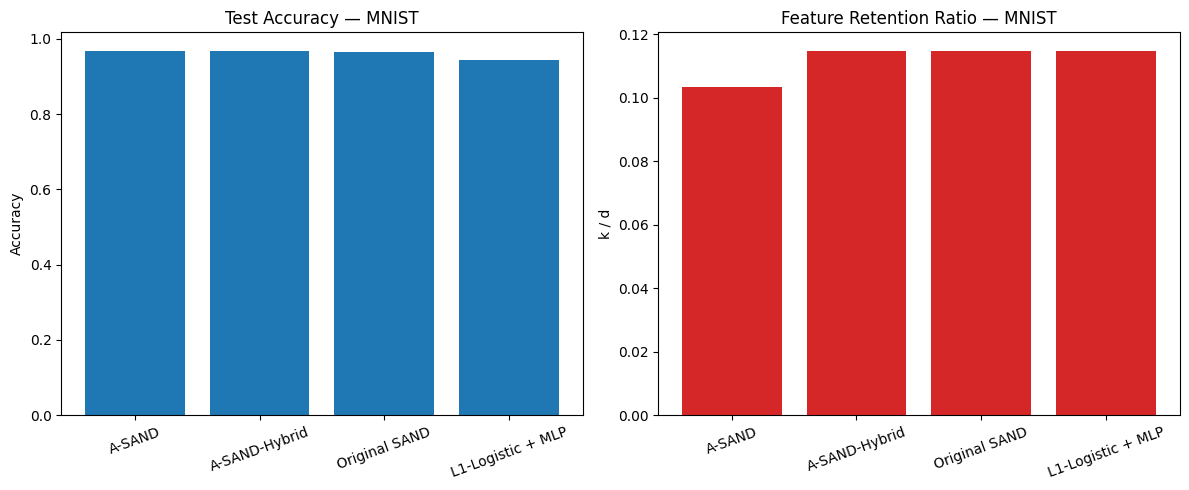

Figure saved to /content/drive/MyDrive/SAND/results/mnist_comparison.png


In [9]:
import matplotlib.pyplot as plt

def render_paper_outputs(df, dataset_name):
    display_df = df[["model", "accuracy", "k", "k_ratio", "time_sec"]].copy()
    display_df.columns = ["Model", "Accuracy", "Final k", "k / d", "Time (s)"]
    display_df["Accuracy"] = display_df["Accuracy"].map(lambda v: f"{v:.4f}")
    display_df["k / d"] = display_df["k / d"].map(lambda v: f"{v:.4f}")
    display_df["Time (s)"] = display_df["Time (s)"].map(lambda v: f"{v:.2f}")

    print(f"Table: Model comparison on {dataset_name.upper()}")
    print(display_df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].bar(df["model"], df["accuracy"], color="#1f77b4")
    axes[0].set_title(f"Test Accuracy — {dataset_name.upper()}")
    axes[0].set_ylabel("Accuracy")
    axes[0].tick_params(axis="x", rotation=20)

    axes[1].bar(df["model"], df["k_ratio"], color="#d62728")
    axes[1].set_title(f"Feature Retention Ratio — {dataset_name.upper()}")
    axes[1].set_ylabel("k / d")
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    out_path = os.path.join(ROOT_PATH, "results", f"{dataset_name}_comparison.png")
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {out_path}")
    return display_df


formatted_table = render_paper_outputs(results_df, DATASET_NAME)

In [10]:
SENS_DATASET = DATASET_NAME          # reuse dataset selected in Section 6
SENS_EPOCHS = 150
SEEDS = [42, 43, 44]

PRUNE_RATES = [0.05, 0.10, 0.15]
LAMBDA_KS = [0.10, 0.15, 0.20]
COOLDOWNS = [2, 3, 5]
PLATEAU_TOLS = [0.001, 0.003, 0.005]

DEFAULTS = dict(prune_rate=0.10, lambda_k=0.15, cooldown=3, plateau_tol=0.003)

SENS_CSV = os.path.join(ROOT_PATH, "results", f"{SENS_DATASET}_sensitivity.csv")
os.makedirs(os.path.dirname(SENS_CSV), exist_ok=True)


def build_sweep_plan():
    plan = []
    for pr in PRUNE_RATES:
        cfg = DEFAULTS.copy(); cfg["prune_rate"] = pr
        plan.append(("prune_rate", pr, cfg))
    for lk in LAMBDA_KS:
        cfg = DEFAULTS.copy(); cfg["lambda_k"] = lk
        plan.append(("lambda_k", lk, cfg))
    for cd in COOLDOWNS:
        cfg = DEFAULTS.copy(); cfg["cooldown"] = cd
        plan.append(("cooldown", cd, cfg))
    for pt in PLATEAU_TOLS:
        cfg = DEFAULTS.copy(); cfg["plateau_tol"] = pt
        plan.append(("plateau_tol", pt, cfg))
    return plan


def append_row_to_csv(row_dict, csv_path):
    row_df = pd.DataFrame([row_dict])
    header = not os.path.exists(csv_path)
    row_df.to_csv(csv_path, mode="a", header=header, index=False)


print(f"Sensitivity sweep will run on dataset: {SENS_DATASET.upper()}")
print(f"Total configs per model: {len(build_sweep_plan())} | Seeds: {SEEDS}")

Sensitivity sweep will run on dataset: MNIST
Total configs per model: 12 | Seeds: [42, 43, 44]


In [11]:
def run_asand_config(ds_train, ds_val, ds_test, num_features, num_classes,
                      prune_rate, lambda_k, cooldown, plateau_tol, seed):
    tf.random.set_seed(seed)
    np.random.seed(seed)

    model = SANDAdaptiveModel(num_inputs=num_features, num_outputs=num_classes,
                               initial_k=num_features, layer_sequence=LAYER_SEQUENCE,
                               is_classification=True)
    model.compile(loss=tf.keras.losses.CategoricalCrossentropy(), metrics=["accuracy"])

    cb = SANDSmartPruningCallback(prune_rate=prune_rate, lambda_k=lambda_k,
                                   cooldown=cooldown, plateau_tol=plateau_tol)

    t0 = time.time()

    model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=SENS_EPOCHS,
        callbacks=[cb],
        verbose=0
    )

    elapsed = time.time() - t0

    res = model.evaluate(
        ds_test,
        return_dict=True,
        verbose=0
    )

    final_k = model.get_feature_importance()["num_selected"]

    return {
        "test_accuracy": res["accuracy"], "final_k": final_k,
        "k_ratio": final_k / num_features, "n_prunes": len(cb.prune_epochs),
        "time_sec": elapsed,
    }


def run_hybrid_config(ds_train, ds_val, ds_test, num_features, num_classes,
                       prune_rate, lambda_k, cooldown, plateau_tol, seed,
                       hybrid_alpha=HYBRID_ALPHA):
    tf.random.set_seed(seed)
    np.random.seed(seed)

    model = SANDAdaptiveModelHybrid(num_inputs=num_features, num_outputs=num_classes,
                                     initial_k=num_features, layer_sequence=LAYER_SEQUENCE,
                                     is_classification=True, batch_norm=False)
    model.compile(metrics=["accuracy"])

    cb = SANDSmartHybridPruningCallback(prune_rate=prune_rate, lambda_k=lambda_k,
                                         cooldown=cooldown, plateau_tol=plateau_tol,
                                         hybrid_alpha=hybrid_alpha)

    t0 = time.time()

    model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=SENS_EPOCHS,
        callbacks=[cb],
        verbose=0
    )

    elapsed = time.time() - t0

    res = model.evaluate(
        ds_test,
        return_dict=True,
        verbose=0
    )

    final_k = model.get_feature_importance()["num_selected"]

    return {
        "test_accuracy": res["accuracy"], "final_k": final_k,
        "k_ratio": final_k / num_features, "n_prunes": len(cb.prune_epochs),
        "time_sec": elapsed,
    }


MODEL_RUNNERS = {"A-SAND": run_asand_config, "A-SAND-Hybrid": run_hybrid_config}
print("Sensitivity runners defined for A-SAND and A-SAND-Hybrid.")

Sensitivity runners defined for A-SAND and A-SAND-Hybrid.


In [ ]:
sens_data = load_prepared_dataset(SENS_DATASET)
sens_ds_train = sens_data["ds_train"]
sens_ds_val = sens_data["ds_val"]
sens_ds_test = sens_data["ds_test"]
sens_num_features = sens_data["num_features"]
sens_num_classes = sens_data["num_classes"]

sweep_plan = build_sweep_plan()
total_runs = len(sweep_plan) * len(SEEDS) * len(MODEL_RUNNERS)
run_counter = 0
print(f"Total runs: {total_runs}\\n")

for model_name, run_fn in MODEL_RUNNERS.items():
    print(f"\\n{'=' * 60}\\nMODEL: {model_name}\\n{'=' * 60}")
    for param_name, param_val, cfg in sweep_plan:
        for seed in SEEDS:
            run_counter += 1
            print(f"[{run_counter}/{total_runs}] {model_name} | {param_name}={param_val} | seed={seed} ...")

            row = run_fn(sens_ds_train, sens_ds_val, sens_ds_test,
                         sens_num_features, sens_num_classes, seed=seed, **cfg)
            row.update(cfg)
            row["model"] = model_name
            row["swept_param"] = param_name
            row["seed"] = seed
            row["dataset"] = SENS_DATASET

            append_row_to_csv(row, SENS_CSV)
            print(
    f"Acc={row['test_accuracy']:.4f}  "
    f"k={row['final_k']}  "
    f"k_ratio={row['k_ratio']:.3f}  "
    f"n_prunes={row['n_prunes']}  "
    f"time={row['time_sec']:.1f}s"
)

print(f"\\nSweep complete. Results saved to {SENS_CSV}")
df_sensitivity = pd.read_csv(SENS_CSV)
df_sensitivity.tail()

Total runs: 72\n
\n============================================================\nMODEL: A-SAND\n============================================================
[1/72] A-SAND | prune_rate=0.05 | seed=42 ...


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:695: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:670: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(



✂️ Pruning: 784 → 745

✂️ Pruning: 745 → 708

✂️ Pruning: 708 → 673

✂️ Pruning: 673 → 640

✂️ Pruning: 640 → 608

✂️ Pruning: 608 → 578

✂️ Pruning: 578 → 550

✂️ Pruning: 550 → 523

✂️ Pruning: 523 → 497

✂️ Pruning: 497 → 473

✂️ Pruning: 473 → 450

✂️ Pruning: 450 → 428

✂️ Pruning: 428 → 407

✂️ Pruning: 407 → 387

✂️ Pruning: 387 → 368

✂️ Pruning: 368 → 350

✂️ Pruning: 350 → 333

✂️ Pruning: 333 → 317

✂️ Pruning: 317 → 302

✂️ Pruning: 302 → 287

✂️ Pruning: 287 → 273


In [ ]:
df_sensitivity = pd.read_csv(SENS_CSV)

summary = (
    df_sensitivity
    .groupby(["model", "swept_param", "prune_rate", "lambda_k", "cooldown", "plateau_tol"])
    .agg(acc_mean=("test_accuracy", "mean"), acc_std=("test_accuracy", "std"),
         k_mean=("final_k", "mean"), k_ratio_mean=("k_ratio", "mean"),
         n_prunes_mean=("n_prunes", "mean"))
    .reset_index()
)
summary["param_value"] = summary.apply(lambda r: r[r["swept_param"]], axis=1)

SUMMARY_CSV = os.path.join(ROOT_PATH, "results", f"{SENS_DATASET}_sensitivity_summary.csv")
summary.to_csv(SUMMARY_CSV, index=False)

for model_name in summary["model"].unique():
    print(f"\\n===== {model_name} — {SENS_DATASET.upper()} =====")
    sub = summary[summary["model"] == model_name].sort_values(["swept_param", "param_value"])
    print(sub[["swept_param", "param_value", "acc_mean", "acc_std", "k_mean", "k_ratio_mean"]].to_string(index=False))

print(f"\\nSummary saved to {SUMMARY_CSV}")

In [ ]:
robustness_rows = []
for model_name in summary["model"].unique():
    for param in ["prune_rate", "lambda_k", "cooldown", "plateau_tol"]:
        sub = summary[(summary["model"] == model_name) & (summary["swept_param"] == param)]
        if len(sub) < 2:
            continue
        robustness_rows.append({
            "model": model_name, "param": param,
            "acc_range_pct": (sub["acc_mean"].max() - sub["acc_mean"].min()) * 100,
            "k_ratio_range_pct": (sub["k_ratio_mean"].max() - sub["k_ratio_mean"].min()) * 100,
        })

robust_df = pd.DataFrame(robustness_rows)
ROBUST_CSV = os.path.join(ROOT_PATH, "results", f"{SENS_DATASET}_robustness.csv")
robust_df.to_csv(ROBUST_CSV, index=False)
print(robust_df.to_string(index=False))
print(f"\\nRobustness table saved to {ROBUST_CSV}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_acc = robust_df.pivot(index="param", columns="model", values="acc_range_pct")
pivot_k = robust_df.pivot(index="param", columns="model", values="k_ratio_range_pct")

pivot_acc.plot(kind="bar", ax=axes[0], color=["#1f77b4", "#d62728"])
axes[0].set_title(f"Accuracy Sensitivity — {SENS_DATASET.upper()}")
axes[0].set_xlabel("Hyperparameter")
axes[0].set_ylabel("Accuracy Range (%)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(True, linestyle="--", alpha=0.4)

pivot_k.plot(kind="bar", ax=axes[1], color=["#1f77b4", "#d62728"])
axes[1].set_title(f"Final-k Ratio Sensitivity — {SENS_DATASET.upper()}")
axes[1].set_xlabel("Hyperparameter")
axes[1].set_ylabel("k-Ratio Range (%)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
fig_path = os.path.join(ROOT_PATH, "results", f"{SENS_DATASET}_sensitivity_comparison.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figure saved to {fig_path}")

In [ ]:
param_labels = {
    "prune_rate": "Prune Rate (\\u03c1)",
    "lambda_k": "Sparsity Penalty (\\u03bb_k)",
    "cooldown": "Cooldown (epochs)",
    "plateau_tol": "Plateau Tolerance (\\u03c4)",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"A-SAND vs A-SAND-Hybrid Hyperparameter Sensitivity — {SENS_DATASET.upper()}",
             fontsize=14, fontweight="bold")

for ax, (param, label) in zip(axes.flat, param_labels.items()):
    for model_name, color in zip(["A-SAND", "A-SAND-Hybrid"], ["#1f77b4", "#d62728"]):
        sub = summary[(summary["model"] == model_name) & (summary["swept_param"] == param)].sort_values("param_value")
        ax.errorbar(sub["param_value"], sub["acc_mean"], yerr=sub["acc_std"],
                     marker="o", label=model_name, color=color, capsize=3)
    ax.set_title(f"Effect of {label} on Test Accuracy")
    ax.set_xlabel(label)
    ax.set_ylabel("Test Accuracy")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.subplots_adjust(top=0.93)
detail_path = os.path.join(ROOT_PATH, "results", f"{SENS_DATASET}_sensitivity_detail.png")
plt.savefig(detail_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figure saved to {detail_path}")